## Обучение модели для FJSPT с использованием подхода RL4CO

In [4]:
import torch
import time
from IPython.display import clear_output

from env import FJSPTEnv

from model import L2DModel
from l2d_policy import L2DPolicy

import matplotlib.pyplot as plt

In [5]:
from rl4co.envs import ENV_REGISTRY

ENV_REGISTRY["fjspt"] = FJSPTEnv

env = FJSPTEnv(
    generator_params={
        "num_jobs": 3,  # the total number of jobs
        "num_machines": 2,  # the total number of machines that can process operations
        "num_trucks": 1,  # the total number of trucks
        "min_ops_per_job": 2,  # minimum number of operatios per job
        "max_ops_per_job": 3,  # maximum number of operations per job
        "min_processing_time": 1,  # the minimum time required for a machine to process an operation
        "max_processing_time": 5,  # the maximum time required for a machine to process an operation
        "min_transportation_time": 0,  # the minimum time required for a truck to transport
        "max_transportation_time": 5,  # the maximum time required for a truck to transport
        "min_eligible_ma_per_op": 1,  # the minimum number of machines capable to process an operation
        "max_eligible_ma_per_op": 2,  # the maximum number of machines capable to process an operation
    },
)

In [6]:
accelerator = "gpu"
batch_size = 128
max_epochs = 50
train_data_size = batch_size * 80
val_data_size = 1_000
test_data_size = 1_000
embed_dim = 128
num_encoder_layers = 4

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Политика диспетчеризации (Learning to Dispatch):
# нейросеть encoder–decoder, выбирающая следующее допустимое назначение операции на машину и транспортное средство
policy = L2DPolicy(embed_dim=embed_dim, num_encoder_layers=num_encoder_layers)
policy = policy.to(device)

# RL-модель Learning to Dispatch:
# обучает политику методом REINFORCE с rollout-бейзлайном,
# оптимизируя makespan через взаимодействие с FJSP-симуляцией
model = L2DModel(
    env,
    policy=policy, 
    baseline="rollout",
    batch_size=batch_size,
    train_data_size=train_data_size,
    val_data_size=val_data_size,
    test_data_size=test_data_size,
    optimizer_kwargs={"lr": 1e-4},
)

/home/egor/cousework/rl4co_try/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/home/egor/cousework/rl4co_try/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


## Тестируем greedy rollout baseline c необученной моделью

**Интерактивное построение решения**

In [8]:
policy.eval()
td = env.reset(batch_size=[1]).to(device)
td1 = td.clone()

with torch.no_grad():
    out = policy(td1, env, phase="test", decode_type="greedy", return_actions=True)

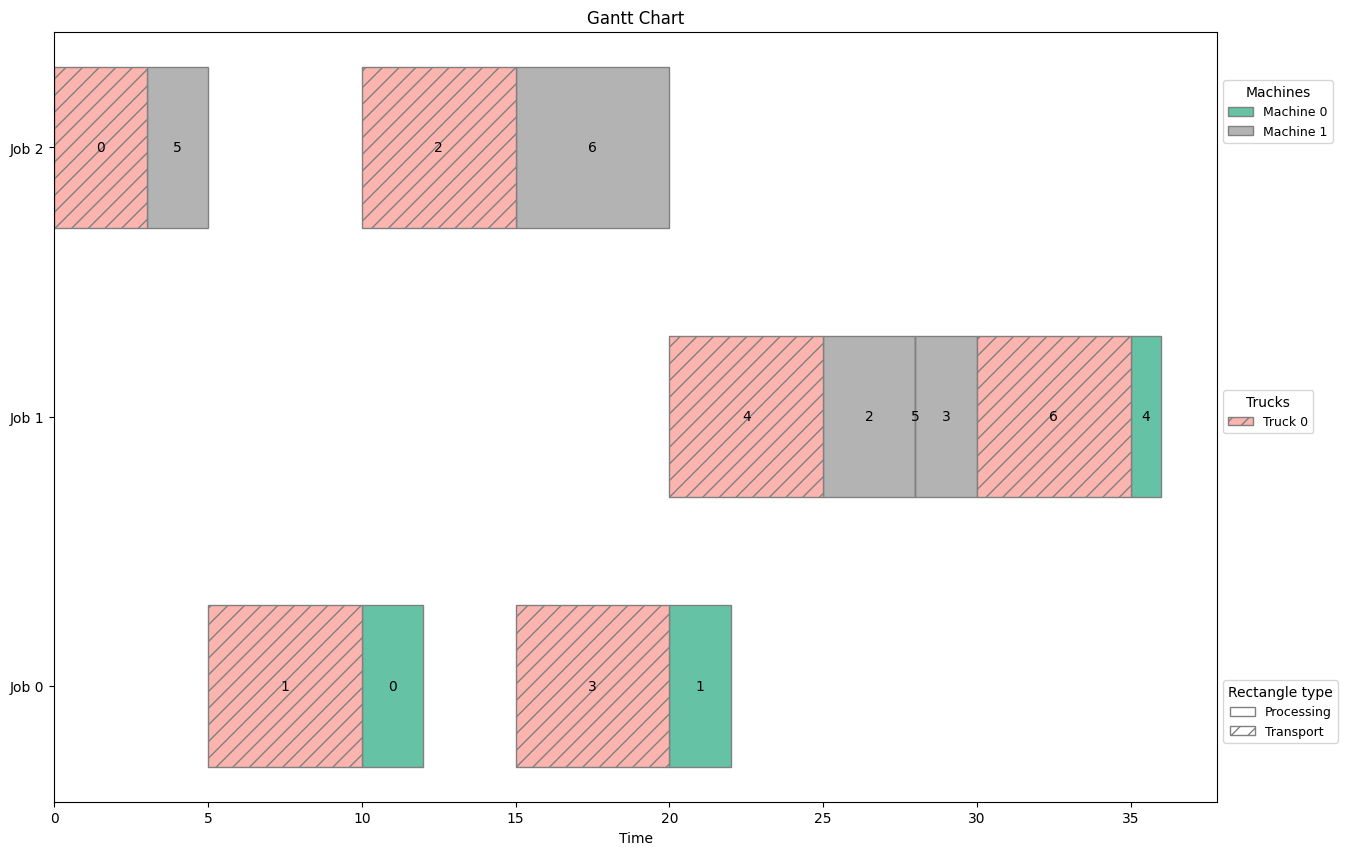

In [9]:
fig = None
env.render(td1.cpu(), 0)
plt.show()

actions = out["actions"]
print(actions)

for step in range(actions.shape[1]):
    td1["action"] = actions[:, step]
    td1 = env.step(td1)["next"]

    clear_output(wait=True)
    if fig is not None:
        plt.close(fig)
    fig = plt.figure()
    _, machine_schedule, trucks_schedule, ops_debug, machine_conflicts, truck_conflicts, job_conflicts = env.render(td1.cpu(), 0)
    plt.show()
    time.sleep(1)

In [10]:
from validation import validate_solution
validate_solution(td1, idx=0, verbose=True)

VALID SOLUTION


True

In [11]:
machine_schedule

defaultdict(list,
            {0: [(0, 10.0, 12.0), (1, 20.0, 22.0), (4, 35.0, 36.0)],
             1: [(2, 25.0, 28.0),
              (3, 28.0, 30.0),
              (5, 3.0, 5.0),
              (6, 15.0, 20.0)]})

In [12]:
trucks_schedule

defaultdict(list,
            {0: [(0, 2, 0.0, 3.0),
              (1, 0, 5.0, 10.0),
              (2, 2, 10.0, 15.0),
              (3, 0, 15.0, 20.0),
              (4, 1, 20.0, 25.0),
              (5, 1, 28.0, 28.0),
              (6, 1, 30.0, 35.0)]})

In [13]:
last_op_finish_times = td1["machine_finish_times"].gather(1, td1["end_op_per_job"])
print("Makespan:", last_op_finish_times.max().item())

Makespan: 36.0


In [14]:
actions_untrained = out['actions'].cpu().detach()
rewards_untrained = out['reward'].cpu().detach()
print(f"Cost: {-rewards_untrained[0]}")

Cost: 36.0
